In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, recall_score
from imblearn.under_sampling import RandomUnderSampler
import optuna

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from warnings import simplefilter

import os
from dotenv import load_dotenv
load_dotenv()

/home/pedro/Documents/projects/churn-ml/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

# Configuração dos Modelos

In [2]:
seed = 42
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=seed, verbose=0),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=seed),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=seed),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=seed),
    "Bagging": BaggingClassifier(n_estimators=100, random_state=seed),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=seed),
    "SVM": SVC(probability=True, random_state=seed),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=seed),
    "LightGBM": LGBMClassifier(random_state=seed),
}


In [3]:
dir_path = os.environ['DATA_WRANGLING_ARTIFACT_PATH']
file_path = os.path.join(dir_path, 'processed_data_head.csv')
del dir_path

In [4]:
df = pd.read_csv(file_path)

# Separar features e target
X = df.drop('Exited', axis=1)
y = df['Exited']

# Dividir em treino e teste
# Dividir em treino, validação e teste (15% validação, 15% teste)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=seed, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15/(1-0.15), random_state=seed, stratify=y_temp)

# Balanceamento das classes (undersampling) apenas no treino
rus = RandomUnderSampler(random_state=seed)
X_train_val, y_train_val = rus.fit_resample(X_train, y_train)

# Treinamento e avaliação dos modelos
def executar_modelo(name, model, X_train_val, y_train_val, X_test, y_test):
    print(f"Treinando: {name}")

    model.fit(X_train_val, y_train_val)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, digits=4)
    
    return report, cm

# Generalização sem Otimização

In [5]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['neg', 'pos'], yticklabels=['neg', 'pos'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()
    plt.close()

## Modelos Clássicos

In [6]:
def calculate_model_cost(cm):
    cost_matrix = [[0, 230], [791.40, 0]]
    return np.sum(cm * cost_matrix)

In [7]:
cost_results = dict()

Treinando: Logistic Regression
              precision    recall  f1-score   support

           0     0.8987    0.6834    0.7764      1194
           1     0.3615    0.6993    0.4766       306

    accuracy                         0.6867      1500
   macro avg     0.6301    0.6914    0.6265      1500
weighted avg     0.7891    0.6867    0.7152      1500



/home/pedro/Documents/projects/churn-ml/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


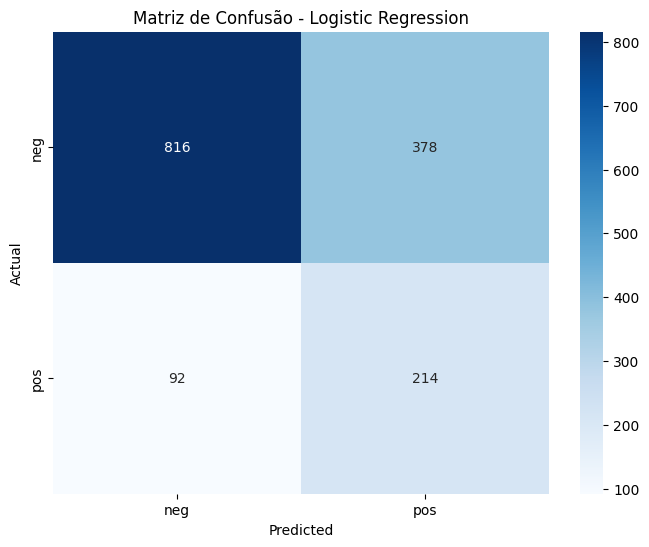

In [8]:
model_name = "Logistic Regression"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")

cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: Random Forest
              precision    recall  f1-score   support

           0     0.9254    0.7789    0.8458      1194
           1     0.4667    0.7549    0.5768       306

    accuracy                         0.7740      1500
   macro avg     0.6960    0.7669    0.7113      1500
weighted avg     0.8318    0.7740    0.7910      1500



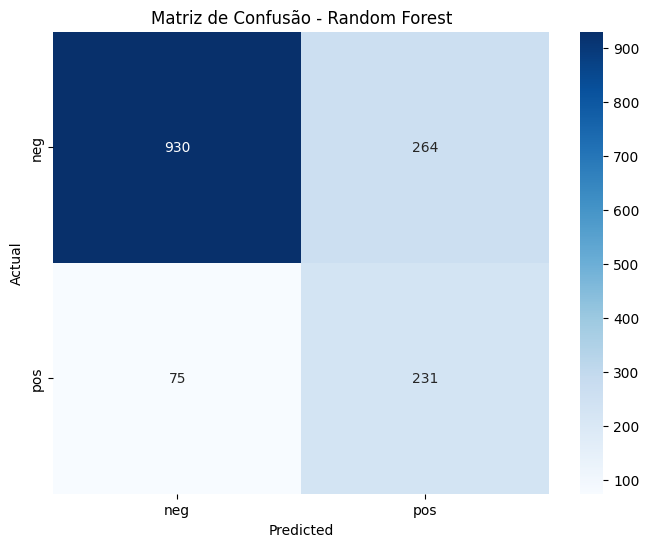

In [9]:
model_name = "Random Forest"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: Gradient Boosting
              precision    recall  f1-score   support

           0     0.9302    0.7814    0.8493      1194
           1     0.4748    0.7712    0.5878       306

    accuracy                         0.7793      1500
   macro avg     0.7025    0.7763    0.7186      1500
weighted avg     0.8373    0.7793    0.7960      1500



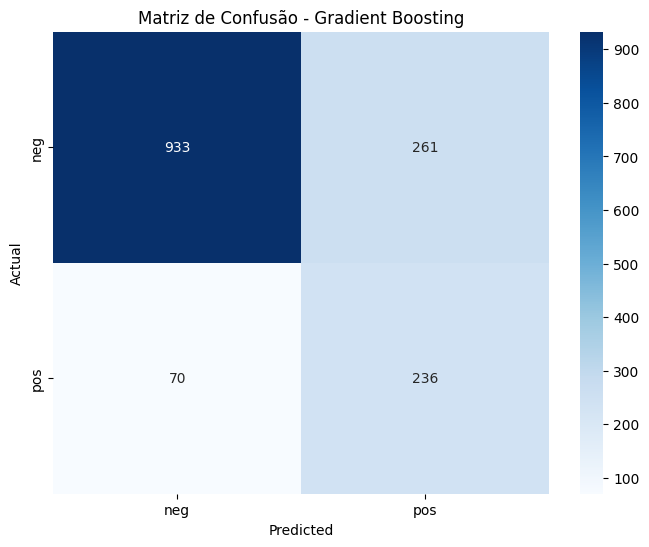

In [10]:
model_name = "Gradient Boosting"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: AdaBoost
              precision    recall  f1-score   support

           0     0.9156    0.7814    0.8432      1194
           1     0.4574    0.7190    0.5591       306

    accuracy                         0.7687      1500
   macro avg     0.6865    0.7502    0.7011      1500
weighted avg     0.8221    0.7687    0.7852      1500



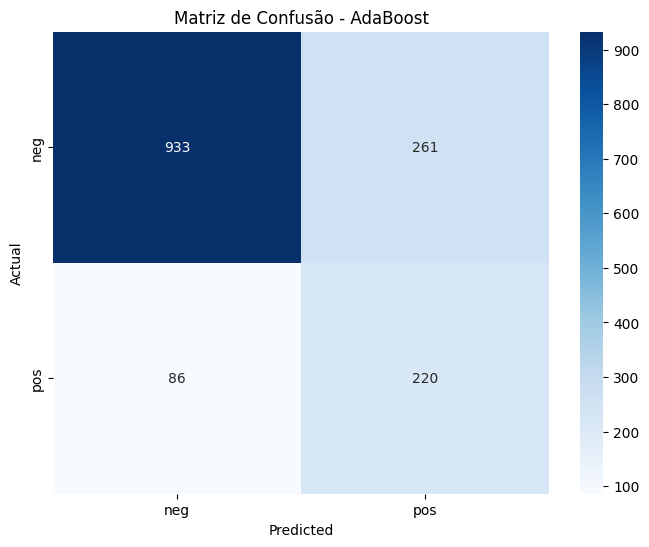

In [11]:
model_name = "AdaBoost"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: Bagging
              precision    recall  f1-score   support

           0     0.9159    0.7839    0.8448      1194
           1     0.4603    0.7190    0.5612       306

    accuracy                         0.7707      1500
   macro avg     0.6881    0.7514    0.7030      1500
weighted avg     0.8229    0.7707    0.7869      1500



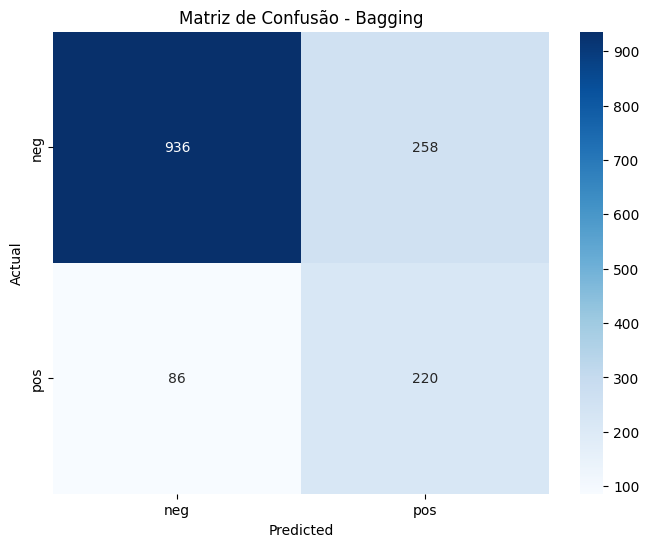

In [12]:
model_name = "Bagging"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: Extra Trees
              precision    recall  f1-score   support

           0     0.9196    0.7755    0.8414      1194
           1     0.4564    0.7353    0.5632       306

    accuracy                         0.7673      1500
   macro avg     0.6880    0.7554    0.7023      1500
weighted avg     0.8251    0.7673    0.7847      1500



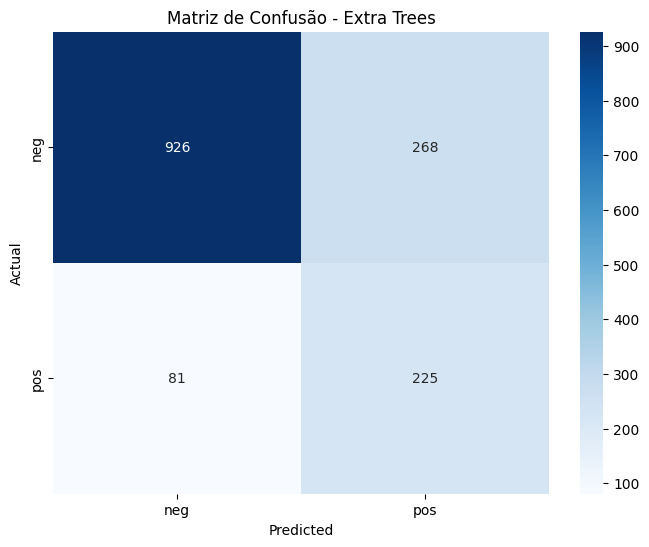

In [13]:
model_name = "Extra Trees"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: SVM
              precision    recall  f1-score   support

           0     0.8429    0.4045    0.5467      1194
           1     0.2330    0.7059    0.3504       306

    accuracy                         0.4660      1500
   macro avg     0.5380    0.5552    0.4485      1500
weighted avg     0.7185    0.4660    0.5066      1500



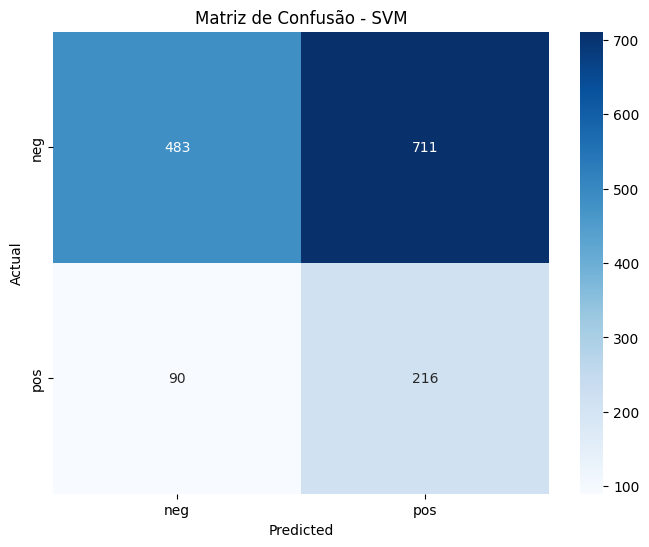

In [14]:
model_name = "SVM"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: KNN
              precision    recall  f1-score   support

           0     0.8029    0.5184    0.6300      1194
           1     0.2112    0.5033    0.2976       306

    accuracy                         0.5153      1500
   macro avg     0.5071    0.5108    0.4638      1500
weighted avg     0.6822    0.5153    0.5622      1500



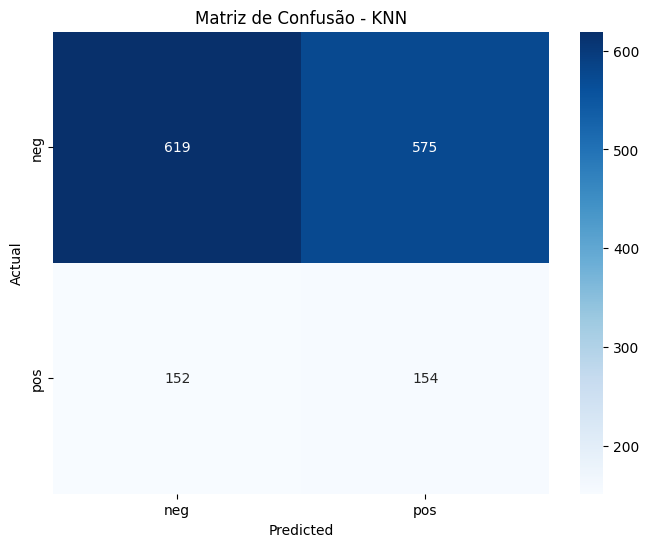

In [15]:
model_name = "KNN"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: XGBoost
              precision    recall  f1-score   support

           0     0.9183    0.7630    0.8335      1194
           1     0.4429    0.7353    0.5528       306

    accuracy                         0.7573      1500
   macro avg     0.6806    0.7491    0.6932      1500
weighted avg     0.8214    0.7573    0.7762      1500



/home/pedro/Documents/projects/churn-ml/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [01:03:00] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


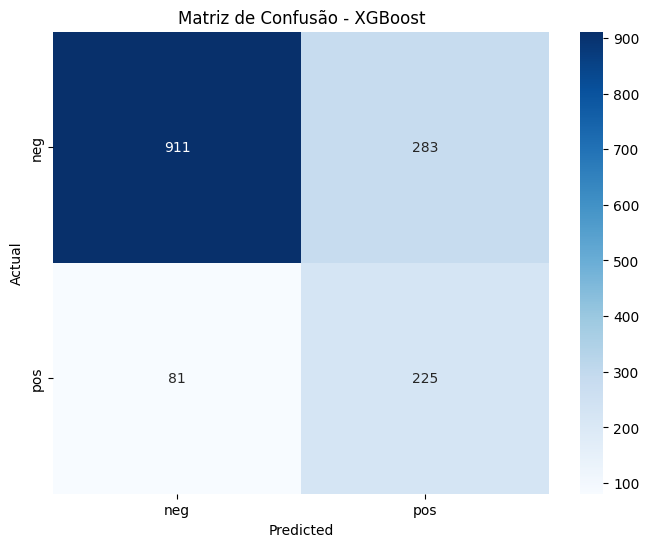

In [16]:
model_name = "XGBoost"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: LightGBM
[LightGBM] [Info] Number of positive: 1426, number of negative: 1426
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000918 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 851
[LightGBM] [Info] Number of data points in the train set: 2852, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
              precision    recall  f1-score   support

           0     0.9224    0.7663    0.8371      1194
           1     0.4508    0.7484    0.5627       306

    accuracy                         0.7627      1500
   macro avg     0.6866    0.7573    0.6999      1500
weighted avg     0.8262    0.7627    0.7811      1500



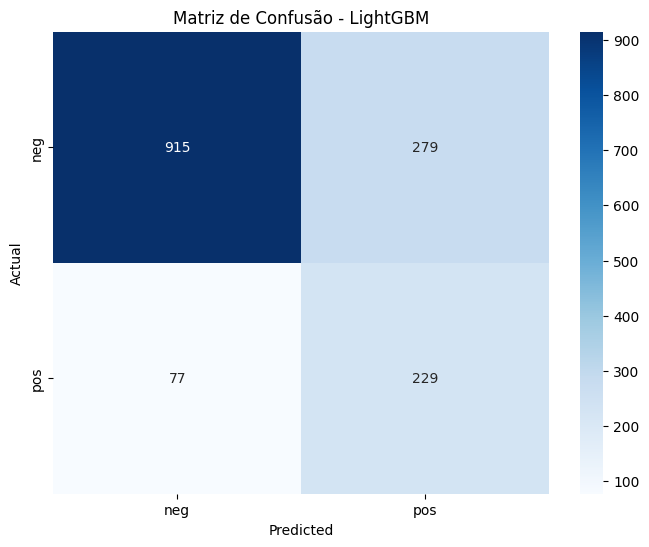

In [17]:
model_name = "LightGBM"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

## Rede Neural

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.nn import sigmoid

2025-10-18 01:03:01.351527: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-18 01:03:01.351851: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-18 01:03:01.385940: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-18 01:03:02.489299: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [19]:
neg_count = np.sum(y_train == 0)
pos_count = np.sum(y_train == 1)
pos_w = neg_count / pos_count
ann_class_weights = {
    0: 1,
    1: pos_w
}
ann_class_weights

{0: 1, 1: np.float64(3.908835904628331)}

In [20]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    verbose=1, 
    restore_best_weights=True, 
    start_from_epoch=10,
    mode='min'
)

In [21]:
model = Sequential([
    Flatten(input_shape=(X_train.shape[1],)),

    Dense(16, activation='relu'),
    
    Dense(1, activation='sigmoid')
])
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy', 'recall', 'precision', 'F1Score']
)

/home/pedro/Documents/projects/churn-ml/venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-10-18 01:03:02.719761: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = model.fit(
    X_train, 
    y_train, 
    epochs=100,
    batch_size=512,
    validation_data=(X_val, y_val), 
    callbacks=[early_stopping],
    class_weight={
        0: 1,
        1: 5
    }
)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - F1Score: 0.2693 - accuracy: 0.4604 - loss: 9611.9375 - precision: 0.1863 - recall: 0.4895 - val_F1Score: 0.2936 - val_accuracy: 0.3873 - val_loss: 5107.6592 - val_precision: 0.1918 - val_recall: 0.6262
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - F1Score: 0.2855 - accuracy: 0.3589 - loss: 7675.5610 - precision: 0.1851 - recall: 0.6311 - val_F1Score: 0.3008 - val_accuracy: 0.3580 - val_loss: 5081.7275 - val_precision: 0.1937 - val_recall: 0.6820
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - F1Score: 0.2880 - accuracy: 0.3453 - loss: 6155.2979 - precision: 0.1855 - recall: 0.6529 - val_F1Score: 0.2988 - val_accuracy: 0.3593 - val_loss: 4321.8892 - val_precision: 0.1929 - val_recall: 0.6754
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - F1Score: 0.2863 - accuracy: 0.3540 - loss: 4636.1743 - precision: 0.1850 - recall: 0.6374 - val_F1Score: 0.2999 - val_accuracy: 0.3727 - val_loss: 3491.7908 - val_precision: 0.1948 

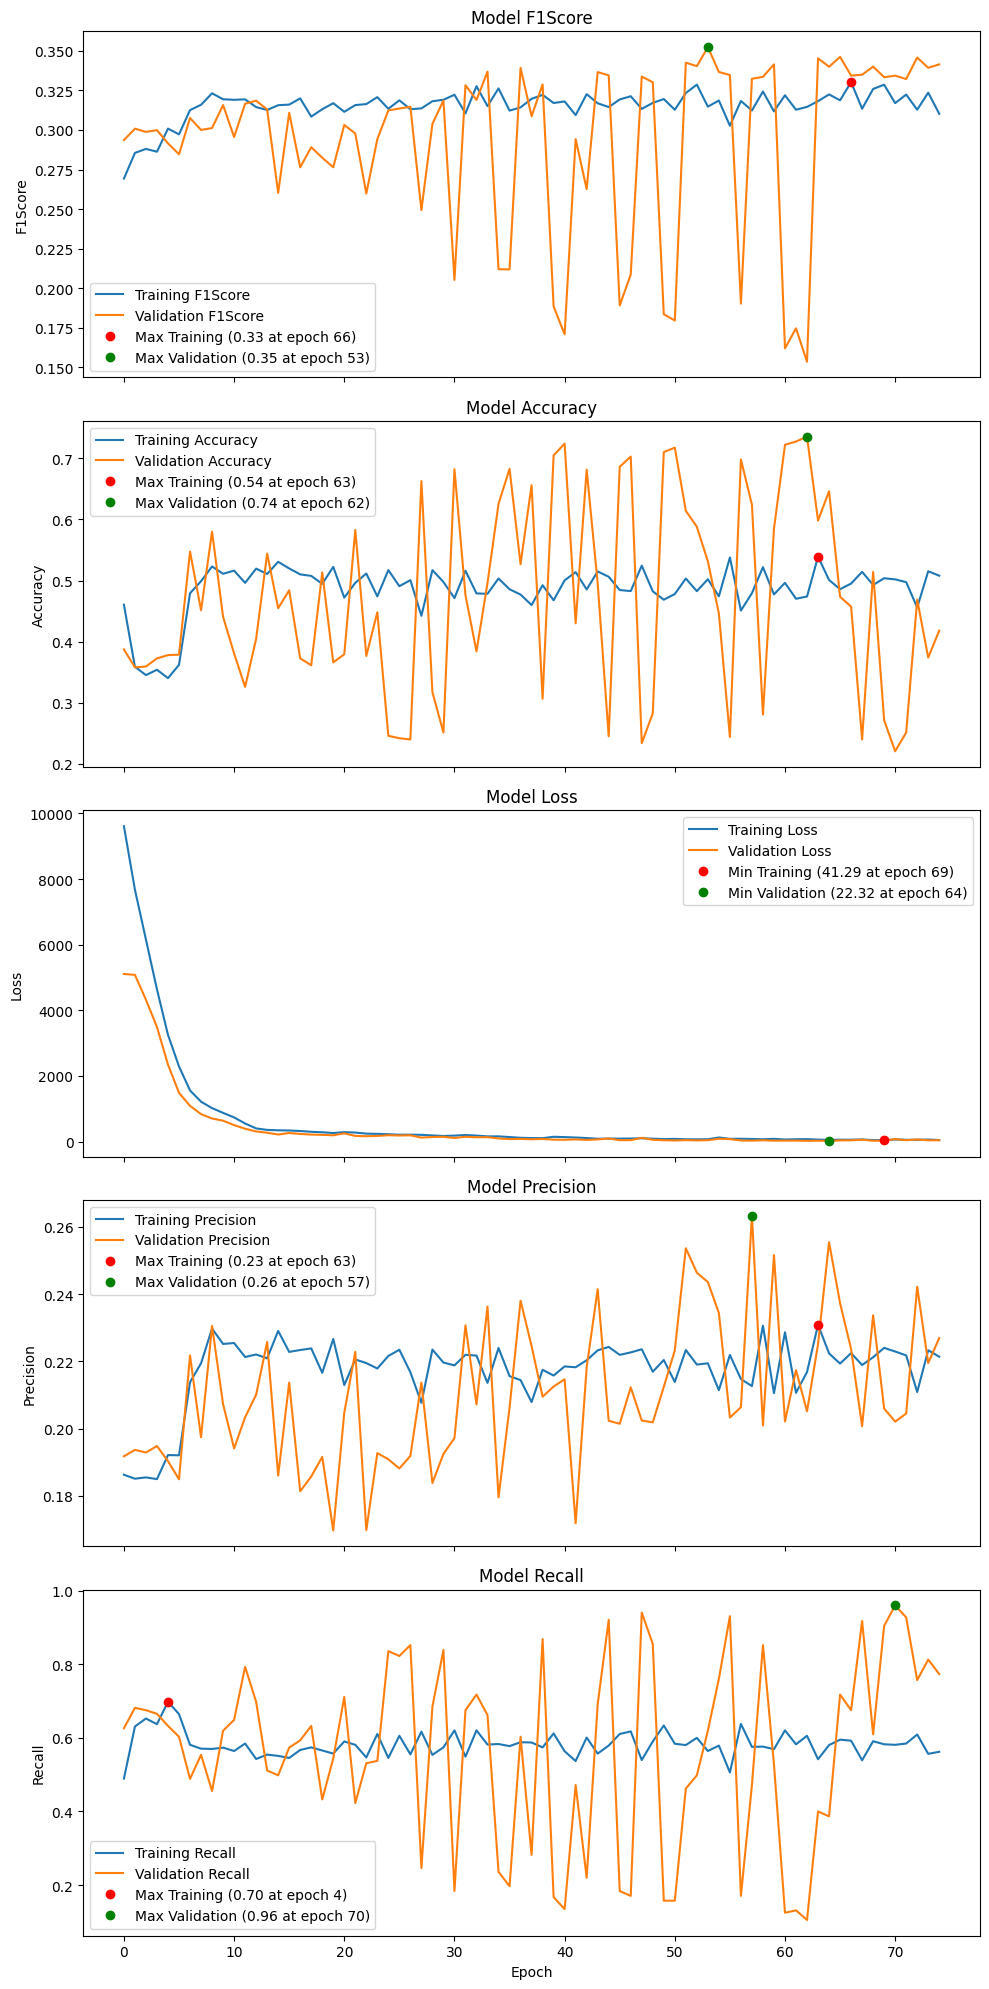

In [24]:
# Plot training and validation metrics on the same subplot for each metric
fig, axes = plt.subplots(len([key for key in history.history.keys() if not 'val' in key]), 1, figsize=(10, 4 * len([key for key in history.history.keys() if not 'val' in key])), sharex=True)

if len([key for key in history.history.keys() if not 'val' in key]) == 1:
    axes = [axes]

metric_names = [metric for metric in history.history.keys() if not 'val' in metric]

for i, metric_name in enumerate(metric_names):
    # Plot training metric
    axes[i].plot(history.history[metric_name], label=f'Training {metric_name.replace("_", " ").title()}')
    # Plot validation metric
    axes[i].plot(history.history[f'val_{metric_name}'], label=f'Validation {metric_name.replace("_", " ").title()}')

    axes[i].set_title(f'Model {metric_name.replace("_", " ").title()}')
    axes[i].set_ylabel(metric_name.replace("_", " ").title())
    axes[i].legend()

    # Add markers for the minimum/maximum on training and validation curves
    if 'loss' in metric_name or 'error' in metric_name: # Find minimum for loss and error metrics
        min_train_value = min(history.history[metric_name])
        min_train_epoch = history.history[metric_name].index(min_train_value)
        axes[i].plot(min_train_epoch, min_train_value, 'ro', label=f'Min Training ({min_train_value:.2f} at epoch {min_train_epoch})')

        min_val_value = min(history.history[f'val_{metric_name}'])
        min_val_epoch = history.history[f'val_{metric_name}'].index(min_val_value)
        axes[i].plot(min_val_epoch, min_val_value, 'go', label=f'Min Validation ({min_val_value:.2f} at epoch {min_val_epoch})')
        axes[i].legend()
    else: # Find maximum for other metrics (like R2)
        max_train_value = max(history.history[metric_name])
        max_train_epoch = history.history[metric_name].index(max_train_value)
        axes[i].plot(max_train_epoch, max_train_value, 'ro', label=f'Max Training ({max_train_value:.2f} at epoch {max_train_epoch})')

        max_val_value = max(history.history[f'val_{metric_name}'])
        max_val_epoch = history.history[f'val_{metric_name}'].index(max_val_value)
        axes[i].plot(max_val_epoch, max_val_value, 'go', label=f'Max Validation ({max_val_value:.2f} at epoch {max_val_epoch})')
        axes[i].legend()


axes[-1].set_xlabel('Epoch')

plt.tight_layout()
plt.show()

In [25]:
dnn_prediction = model.predict(X_test)
dnn_probabilities = sigmoid(dnn_prediction).numpy()
dnn_predicted_classes = (dnn_probabilities > 0.5).astype(int)
print(classification_report(y_test, dnn_predicted_classes))

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.82      0.49      0.61      1194
           1       0.22      0.58      0.32       306

    accuracy                           0.51      1500
   macro avg       0.52      0.53      0.47      1500
weighted avg       0.70      0.51      0.55      1500



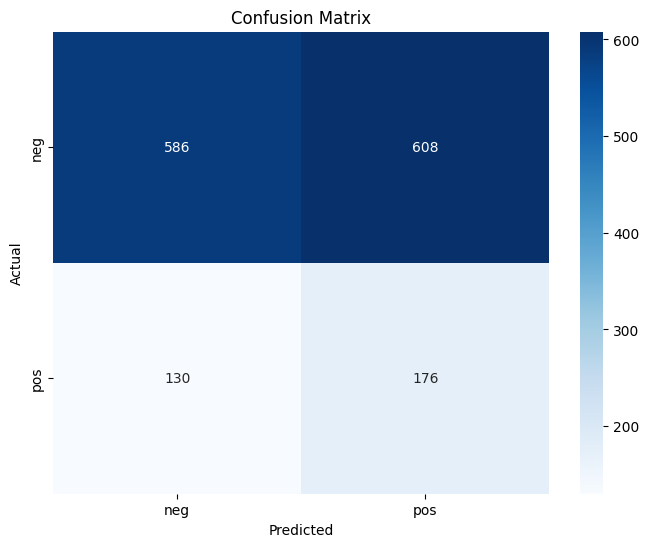

In [26]:
cm = confusion_matrix(y_test, dnn_predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['neg', 'pos'], yticklabels=['neg', 'pos'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [27]:
cost_results[f"Rede Neural"] = calculate_model_cost(cm)

# Otimização de Hiperparâmetros

In [28]:
param_grids = {
    "Logistic Regression": {
        "model_instance": LogisticRegression(verbose=0),
        "params": lambda trial:{
            "C": trial.suggest_float("C", 1e-4, 1e2),
            "penalty": trial.suggest_categorical("penalty", ["l1", "l2"]),
            "solver": trial.suggest_categorical("solver", ["liblinear", "saga"]),
            "max_iter": trial.suggest_int("max_iter", 100, 2000),
        }
    },
    "Random Forest": {
        "model_instance": RandomForestClassifier(verbose=0),
        "params": lambda trial:{
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 2, 32, log=True),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
            "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        }
    },
    "Gradient Boosting": {
        "model_instance": GradientBoostingClassifier(verbose=0),
        "params": lambda trial:{
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 1.0),
            "max_depth": trial.suggest_int("max_depth", 2, 16),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        }
    },
    "AdaBoost": {
        "model_instance": AdaBoostClassifier(),
        "params": lambda trial:{
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 1.0),
        }
    },
    "Bagging": {
        "model_instance": BaggingClassifier(verbose=0),
        "params": lambda trial:{
            "n_estimators": trial.suggest_int("n_estimators", 10, 200),
            "max_samples": trial.suggest_float("max_samples", 0.5, 1.0),
            "max_features": trial.suggest_float("max_features", 0.5, 1.0),
            "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        }
    },
    "Extra Trees": {
        "model_instance": ExtraTreesClassifier(verbose=0),
        "params": lambda trial:{
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 2, 32, log=True),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
            "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        }
    },
    "KNN": {
        "model_instance": KNeighborsClassifier(),
        "params": lambda trial:{
            "n_neighbors": trial.suggest_int("n_neighbors", 2, 30),
            "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
            "p": trial.suggest_int("p", 1, 2),
        }
    },
    "XGBoost": {
        "model_instance": XGBClassifier(verbosity=0, use_label_encoder=False),
        "params": lambda trial:{
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 2, 16),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 1.0),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "gamma": trial.suggest_float("gamma", 1e-8, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0),
        }
    },
    "LightGBM": {
        "model_instance": LGBMClassifier(),
        "params": lambda trial:{
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 2, 32),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 1.0),
            "num_leaves": trial.suggest_int("num_leaves", 7, 256),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0),
        }
    },
    # "SVM": {
    #     "model_instance": SVC(verbose=0),
    #     "params": lambda trial:{
    #         "C": trial.suggest_float("C", 1e-4, 1e2),
    #         "kernel": trial.suggest_categorical("kernel", ["linear", "rbf", "sigmoid"]),
    #         "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
    #         "degree": trial.suggest_int("degree", 2, 5),
    #     }
    # },
}

In [29]:
def objective(trial, model_instance, param_grid, X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val):
    params = param_grid(trial)
    clf = model_instance.__class__(**params)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)
    
    return recall_score(y_val, y_pred, pos_label=1)

In [32]:
tuning_results = dict()

simplefilter(action='ignore')
for model_name, clf_data in list(param_grids.items()):
    print(f'Otimizando: {model_name}')
    study = optuna.create_study(direction='maximize')
    
    study.optimize(lambda trial: objective(trial, clf_data['model_instance'], clf_data['params']), n_trials=300)
    best_params = study.best_params
    trials = study.trials_dataframe()
    tuning_results[model_name] = dict()
    tuning_results[model_name]['best_params'] = best_params


[I 2025-10-18 01:10:44,319] A new study created in memory with name: no-name-ac8f8409-5fd0-4e48-82f0-237e7a15f35a
[I 2025-10-18 01:10:44,391] Trial 0 finished with value: 0.06557377049180328 and parameters: {'C': 36.50215336436135, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 625}. Best is trial 0 with value: 0.06557377049180328.
[I 2025-10-18 01:10:44,423] Trial 1 finished with value: 0.06557377049180328 and parameters: {'C': 92.33897141589011, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 750}. Best is trial 0 with value: 0.06557377049180328.
[I 2025-10-18 01:10:44,445] Trial 2 finished with value: 0.06557377049180328 and parameters: {'C': 30.08054217917217, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 216}. Best is trial 0 with value: 0.06557377049180328.
[I 2025-10-18 01:10:44,490] Trial 3 finished with value: 0.22950819672131148 and parameters: {'C': 12.587647373025366, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 325}. Best is trial 3 with value: 0.2295

Otimizando: Logistic Regression


[I 2025-10-18 01:10:44,871] Trial 5 finished with value: 0.0 and parameters: {'C': 11.1332159191441, 'penalty': 'l1', 'solver': 'saga', 'max_iter': 449}. Best is trial 3 with value: 0.22950819672131148.
[I 2025-10-18 01:10:45,413] Trial 6 finished with value: 0.0 and parameters: {'C': 49.18269367356564, 'penalty': 'l1', 'solver': 'saga', 'max_iter': 727}. Best is trial 3 with value: 0.22950819672131148.
[I 2025-10-18 01:10:45,551] Trial 7 finished with value: 0.0 and parameters: {'C': 11.097543700613219, 'penalty': 'l2', 'solver': 'saga', 'max_iter': 201}. Best is trial 3 with value: 0.22950819672131148.
[I 2025-10-18 01:10:46,021] Trial 8 finished with value: 0.0 and parameters: {'C': 37.119355826112006, 'penalty': 'l1', 'solver': 'saga', 'max_iter': 577}. Best is trial 3 with value: 0.22950819672131148.
[I 2025-10-18 01:10:46,058] Trial 9 finished with value: 0.06557377049180328 and parameters: {'C': 60.196497716808, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 806}. Best is t

Otimizando: Random Forest


[I 2025-10-18 01:11:16,885] Trial 0 finished with value: 0.4426229508196721 and parameters: {'n_estimators': 297, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 9, 'bootstrap': True}. Best is trial 0 with value: 0.4426229508196721.
[I 2025-10-18 01:11:18,937] Trial 1 finished with value: 0.4885245901639344 and parameters: {'n_estimators': 246, 'max_depth': 17, 'min_samples_split': 9, 'min_samples_leaf': 4, 'bootstrap': False}. Best is trial 1 with value: 0.4885245901639344.
[I 2025-10-18 01:11:19,620] Trial 2 finished with value: 0.4819672131147541 and parameters: {'n_estimators': 114, 'max_depth': 27, 'min_samples_split': 17, 'min_samples_leaf': 3, 'bootstrap': True}. Best is trial 1 with value: 0.4885245901639344.
[I 2025-10-18 01:11:19,833] Trial 3 finished with value: 0.24262295081967214 and parameters: {'n_estimators': 90, 'max_depth': 3, 'min_samples_split': 15, 'min_samples_leaf': 9, 'bootstrap': True}. Best is trial 1 with value: 0.4885245901639344.
[I 2025-10-18 

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-10-18 01:51:06,569] Trial 298 finished with value: 0.5245901639344263 and parameters: {'n_estimators': 185, 'max_depth': 21, 'learning_rate': 0.8538278212558792, 'num_leaves': 236, 'subsample': 0.901616026756716, 'colsample_bytree': 0.721785150152543, 'reg_alpha': 0.7055834183803449, 'reg_lambda': 0.6882644740033173}. Best is trial 66 with value: 0.5606557377049181.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000138 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 856
[LightGBM] [Info] Number of data points in the train set: 7000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203714 -> initscore=-1.363240
[LightGBM] [Info] Start training from score -1.363240
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

[I 2025-10-18 01:51:06,742] Trial 299 finished with value: 0.5278688524590164 and parameters: {'n_estimators': 180, 'max_depth': 24, 'learning_rate': 0.8289638137722746, 'num_leaves': 240, 'subsample': 0.5820291271755667, 'colsample_bytree': 0.718920769595497, 'reg_alpha': 0.6879299222306665, 'reg_lambda': 0.6676476090935934}. Best is trial 66 with value: 0.5606557377049181.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

## Métricas dos Modelos Otimizados

In [36]:
for key, value in tuning_results.items():
    print(key, value)
    results = tuning_results[key]
    best_params = results['best_params']
    
    model = param_grids[key]['model_instance'].__class__(**best_params)

    model.fit(X_train, y_train)
    prediction = model.predict(X_test)

    # print(classification_report(y_test, prediction))

    cm = confusion_matrix(y_test, prediction)
    # plot_confusion_matrix(cm, 'Matriz de Confusão')

    cost_matrix = [[0, 230], [791.40, 0]]
    cost_result = np.sum(cm * cost_matrix)
    cost_results[f"Optmized_{key}"] = cost_result

Logistic Regression {'best_params': {'C': 12.587647373025366, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 325}}
Random Forest {'best_params': {'n_estimators': 246, 'max_depth': 26, 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': False}}
Gradient Boosting {'best_params': {'n_estimators': 262, 'learning_rate': 0.9076894009750107, 'max_depth': 9, 'subsample': 0.5160803085247034, 'min_samples_split': 4, 'min_samples_leaf': 17}}
AdaBoost {'best_params': {'n_estimators': 196, 'learning_rate': 0.9751270316367058}}
Bagging {'best_params': {'n_estimators': 61, 'max_samples': 0.9998878485842925, 'max_features': 0.9821125184375665, 'bootstrap': False}}
Extra Trees {'best_params': {'n_estimators': 299, 'max_depth': 32, 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': False}}
KNN {'best_params': {'n_neighbors': 2, 'weights': 'distance', 'p': 2}}
XGBoost {'best_params': {'n_estimators': 247, 'max_depth': 4, 'learning_rate': 0.7736533024284736, 'subsample': 0.5457157989

In [38]:
cost_results_df = pd.DataFrame(list(cost_results.items()), columns=['Modelo', 'Custo dos Erros'])
cost_results_df = cost_results_df.sort_values(by='Custo dos Erros', ascending=True)
cost_results_df.reset_index(drop=True, inplace=True)
cost_results_df['Custo dos Erros'] = cost_results_df['Custo dos Erros'].apply(lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
cost_results_df


,Modelo,Custo dos Erros
0,Baseline_Gradient Boosting,"R$ 115.428,00"
1,Baseline_Random Forest,"R$ 120.075,00"
2,Baseline_LightGBM,"R$ 125.107,80"
3,Baseline_Extra Trees,"R$ 125.743,40"
4,Baseline_Bagging,"R$ 127.400,40"
5,Baseline_AdaBoost,"R$ 128.090,40"
6,Baseline_XGBoost,"R$ 129.193,40"
7,Optmized_LightGBM,"R$ 135.601,40"
8,Optmized_Random Forest,"R$ 143.258,20"
9,Optmized_AdaBoost,"R$ 145.382,60"
